# STQD-Det v3 — Evaluation on dataset2_split (test)

Checkpoint: `stqd_det/runs/stqd_v3/best.pt` (epoch 9, val_loss=4.0844)

In [1]:
import sys, json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, ".")
from stqd_det.config import Config
from stqd_det.dataset import get_dataloader
from stqd_det.model.detector import STQDDet
from stqd_det.evaluate import evaluate

/home/dsa/miniconda3/envs/stenosis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Training history

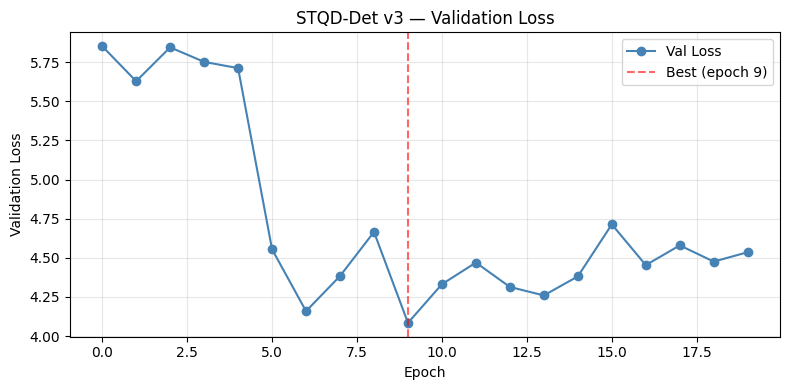

In [2]:
metrics_csv = pd.read_csv("stqd_det/runs/stqd_v3/metrics.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_csv["epoch"], metrics_csv["val/loss"], "o-", color="steelblue", label="Val Loss")
ax.axvline(9, color="red", linestyle="--", alpha=0.6, label="Best (epoch 9)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("STQD-Det v3 — Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Load model & run evaluation on test set

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(
    "stqd_det/runs/stqd_v3/best.pt",
    map_location=device, weights_only=False,
)

cfg = Config(**ckpt.get("config", {})) if "config" in ckpt else Config()
cfg.data_root = Path("data/dataset2_split")
print(f"Config: T={cfg.T}, num_proposals={cfg.num_proposals}, decoder_layers={cfg.decoder_layers}")
print(f"Score thresh: {cfg.score_thresh}, NMS thresh: {cfg.nms_thresh}")

model = STQDDet(cfg).to(device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best checkpoint (epoch {ckpt.get('epoch', '?')})")

Config: T=9, num_proposals=100, decoder_layers=6
Score thresh: 0.5, NMS thresh: 0.5
Loaded best checkpoint (epoch 9)


In [4]:
loader = get_dataloader("test", cfg, shuffle=False)
print(f"Test windows: {len(loader.dataset)}, batches: {len(loader)}")

[test] 31 sequences, 1252 frames, 1006 windows of T=9 (1252 images cached)
Test windows: 1006, batches: 503


In [5]:
metrics = evaluate(model, loader, device, cfg)
metrics

Evaluating: 100%|██████████| 503/503 [02:22<00:00,  3.53it/s]


{'precision': 0.0, 'recall': 0.0, 'F1': 0.0}

## 3. Results summary

In [6]:
summary = pd.DataFrame([
    {"Metric": k, "Value": f"{v:.4f}" if isinstance(v, float) else str(v)}
    for k, v in metrics.items()
])
summary.style.hide(axis="index")

Metric,Value
precision,0.0000
recall,0.0000
F1,0.0000


/tmp/ipykernel_496772/3786653643.py:6: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(bar_metrics.values()) * 1.3 if bar_metrics.values() else 1.0)


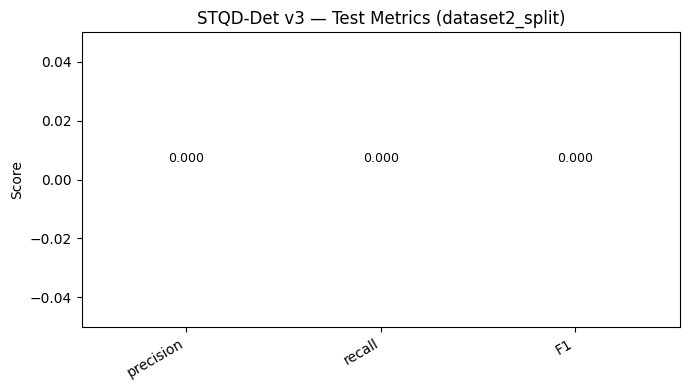

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

bar_metrics = {k: v for k, v in metrics.items() if isinstance(v, float)}

bars = ax.bar(bar_metrics.keys(), bar_metrics.values(), color="steelblue")
ax.set_ylim(0, max(bar_metrics.values()) * 1.3 if bar_metrics.values() else 1.0)
ax.set_ylabel("Score")
ax.set_title("STQD-Det v3 — Test Metrics (dataset2_split)")

for bar, val in zip(bars, bar_metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Save metrics
out_path = "stqd_det/runs/stqd_v3/eval_dataset2_split_test.json"
with open(out_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved to {out_path}")

## 4. Threshold sensitivity analysis

Evaluate at different score thresholds to find the optimal operating point.

In [ ]:
from stqd_det.evaluate import compute_ap_per_frame
from tqdm import tqdm

# Collect all raw predictions (before threshold) and ground truth
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds = []  # list of (predictions_T, gt_boxes_T, gt_labels_T)
    for images, targets in tqdm(loader, desc="Collecting predictions"):
        images = images.to(device)
        B, T = images.shape[0], images.shape[1]
        results = model(images)
        for b in range(B):
            gt_boxes = [targets[b][t]["boxes"].to(device) for t in range(T)]
            gt_labels = [targets[b][t]["labels"].to(device) for t in range(T)]
            all_preds.append((results[b], gt_boxes, gt_labels))
    return all_preds

all_predictions = collect_predictions(model, loader, device)

In [ ]:
# Sweep thresholds on already-collected predictions
def eval_at_threshold(all_predictions, score_thr):
    agg = {"precision": 0.0, "recall": 0.0, "F1": 0.0}
    n = 0
    for preds_T, gt_boxes_T, gt_labels_T in all_predictions:
        # Filter predictions by threshold
        filtered = []
        for p in preds_T:
            mask = p["scores"] >= score_thr
            filtered.append({
                "boxes": p["boxes"][mask],
                "scores": p["scores"][mask],
                "labels": p["labels"][mask],
            })
        m = compute_ap_per_frame(filtered, gt_boxes_T, gt_labels_T, iou_thresh=0.5)
        for k in agg:
            agg[k] += m[k]
        n += 1
    return {k: v / max(n, 1) for k, v in agg.items()}

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7]
sweep_results = {t: eval_at_threshold(all_predictions, t) for t in thresholds}

sweep_df = pd.DataFrame([
    {"Threshold": t, **{k: f"{v:.4f}" for k, v in r.items()}}
    for t, r in sweep_results.items()
])
sweep_df.style.hide(axis="index")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

prec_vals = [sweep_results[t]["precision"] for t in thresholds]
rec_vals = [sweep_results[t]["recall"] for t in thresholds]
f1_vals = [sweep_results[t]["F1"] for t in thresholds]

ax.plot(thresholds, prec_vals, "o-", label="Precision", color="#4C72B0")
ax.plot(thresholds, rec_vals, "s-", label="Recall", color="#DD8452")
ax.plot(thresholds, f1_vals, "D-", label="F1", color="#55A868", linewidth=2)

best_thr = thresholds[np.argmax(f1_vals)]
best_f1 = max(f1_vals)
ax.axvline(best_thr, color="red", linestyle="--", alpha=0.5, label=f"Best F1 @ {best_thr}")
ax.annotate(f"F1={best_f1:.3f}", xy=(best_thr, best_f1),
            xytext=(best_thr + 0.05, best_f1 + 0.03), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="red"))

ax.set_xlabel("Score Threshold")
ax.set_ylabel("Score")
ax.set_title("STQD-Det v3 — Threshold Sensitivity (dataset2_split test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best F1 = {best_f1:.4f} at threshold = {best_thr}")

## 5. Comparison with RF-DETR and Stenosis Temporal

Compare STQD-Det v3 with other models evaluated on the same `dataset2_split` test set.

In [ ]:
# Load other models' metrics if available
other_evals = {}

temporal_path = Path("stenosis_temporal/runs/stenosis_temporal_1/eval_dataset2_split_test.json")
if temporal_path.exists():
    with open(temporal_path) as f:
        other_evals["Stenosis Temporal"] = json.load(f)

# RF-DETR from metrics.csv
rfdetr_augs_csv_path = Path("rfdetr_runs/dataset2_augs/metrics.csv")
rfdetr_trainval_csv_path = Path("rfdetr_runs/arcade_dataset2_trainval/metrics.csv")

def get_rfdetr_test_metrics(csv_path):
    df = pd.read_csv(csv_path)
    test_rows = df.dropna(subset=["test/mAP_50"])
    if len(test_rows) == 0:
        return None
    best = test_rows.loc[test_rows["test/mAP_50"].idxmax()]
    return {
        "precision": best["test/precision"],
        "recall": best["test/recall"],
        "F1": best["test/F1"],
    }

if rfdetr_augs_csv_path.exists():
    m = get_rfdetr_test_metrics(rfdetr_augs_csv_path)
    if m:
        other_evals["RF-DETR (dataset2_augs)"] = m

if rfdetr_trainval_csv_path.exists():
    m = get_rfdetr_test_metrics(rfdetr_trainval_csv_path)
    if m:
        other_evals["RF-DETR (arcade+ds2 trainval)"] = m

# Build comparison
stqd_metrics = {"precision": metrics["precision"], "recall": metrics["recall"], "F1": metrics["F1"]}
all_models = {"STQD-Det v3": stqd_metrics, **other_evals}

comp_data = {"Metric": ["Precision", "Recall", "F1"]}
for name, m in all_models.items():
    comp_data[name] = [f"{m['precision']:.4f}", f"{m['recall']:.4f}", f"{m['F1']:.4f}"]

comparison = pd.DataFrame(comp_data)
comparison.style.hide(axis="index")

In [ ]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))

metric_names = ["Precision", "Recall", "F1"]
x = np.arange(len(metric_names))
n_models = len(all_models)
width = 0.8 / n_models
colors_list = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for i, (name, m) in enumerate(all_models.items()):
    vals = [m["precision"], m["recall"], m["F1"]]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name, color=colors_list[i % len(colors_list)])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Model Comparison — dataset2_split test set")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis="y")
ymax = max(max(m["precision"], m["recall"], m["F1"]) for m in all_models.values()) * 1.25
ax.set_ylim(0, min(ymax, 1.0))
plt.tight_layout()
plt.show()